In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Input, LSTM
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D
from tensorflow.keras.layers import Embedding, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from matplotlib import pyplot as plt
from pandas import DataFrame
import pickle as pickle
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from sklearn import preprocessing,metrics
pd.set_option("display.max_columns", 100)
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
%matplotlib inline
from sklearn import linear_model,svm
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import average_precision_score, classification_report,confusion_matrix
from scipy.stats import skew
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from tqdm import tqdm
from nltk import word_tokenize
from sklearn.multiclass import OneVsRestClassifier


In [ ]:
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
data = pd.read_csv('/content/train.csv').fillna(' ')
label= data[['toxic', 'severe_toxic' , 'obscene' , 'threat' , 'insult' , 'identity_hate']]

In [ ]:
print(data.shape)

(159571, 8)


In [ ]:
import nltk
nltk.download('punkt_tab')
comment=data['comment_text']
x = [len(word_tokenize(comment[i])) for i in range(comment.shape[0])]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Average length of comment: 80.351


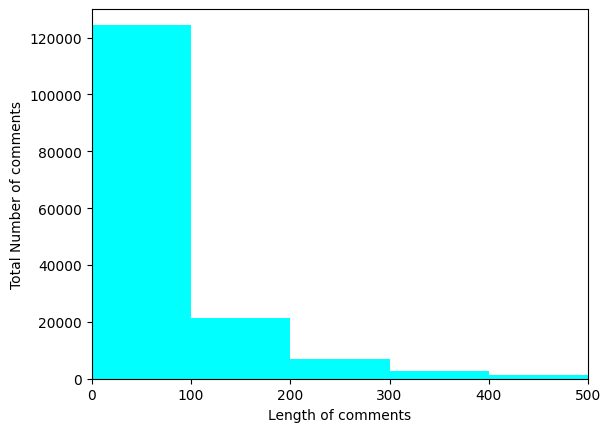

In [ ]:
print('Average length of comment: {:.3f}'.format(sum(x)/len(x)) )
bins = [1,100,200,300,400,500]
plt.hist(x, bins=bins,color='aqua')
plt.xlabel('Length of comments')
plt.ylabel('Total Number of comments')
plt.axis([0, 500, 0, 130000])
plt.show()

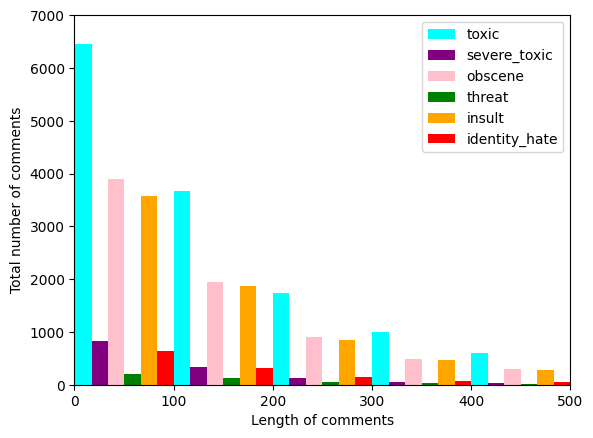

In [ ]:
label=np.array(label)
y = np.zeros(label.shape)
for ix in range(comment.shape[0]):
    l = len(comment[ix])
    if label[ix][0] :
        y[ix][0] = l
    if label[ix][1] :
        y[ix][1] = l
    if label[ix][2] :
        y[ix][2] = l
    if label[ix][3] :
        y[ix][3] = l
    if label[ix][4] :
        y[ix][4] = l
    if label[ix][5] :
        y[ix][5] = l

color = ['aqua','purple','pink','green','orange','red']
plt.hist(y,bins = bins,label = classes,color = color, rwidth=5)
plt.axis([0, 500, 0, 7000])
plt.xlabel('Length of comments')
plt.ylabel('Total number of comments')
plt.legend()
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split

#  Cleaning data
data['comment_text'] = data['comment_text'].fillna(" ")

# train and split
X_train, X_test, y_train, y_test = train_test_split(
    data["comment_text"],
    data[classes],
    test_size=0.1,
    random_state=76
)


print("--- Data Split Results ---")
print(f"X_train (Text) shape: {X_train.shape}")
print(f"y_train (Labels) shape: {y_train.shape}")
print(f"X_test (Text) shape: {X_test.shape}")
print(f"y_test (Labels) shape: {y_test.shape}")

#  show statistics
print("\n--- Label Distribution ---")
print(data[classes].sum())

--- Data Split Results ---
X_train (Text) shape: (143613,)
y_train (Labels) shape: (143613, 6)
X_test (Text) shape: (15958,)
y_test (Labels) shape: (15958, 6)

--- Label Distribution ---
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


train = pd.read_csv('train.csv')
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Separate the classes
toxic_df = train[train[list_classes].sum(axis=1) > 0]
clean_df = train[train[list_classes].sum(axis=1) == 0]

# Balance to 50/50 
balanced_df = pd.concat([
    toxic_df,
    clean_df.sample(len(toxic_df), random_state=42)
])

#  Shuffle
balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

print(f"Total balanced rows: {len(balanced_df)}")

Total balanced rows: 32450


In [ ]:
#embeddings
max_words = 20000
maxlen = 200
embedding_dim = 300 

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(balanced_df["comment_text"].values)

X_bal = tokenizer.texts_to_sequences(balanced_df["comment_text"].values)
X_bal = pad_sequences(X_bal, maxlen=maxlen)
y_bal = balanced_df[list_classes].values



In [ ]:
embeddings_index = {}
corrupt_lines = 0


with open('glove.6B.300d.txt', encoding='utf8') as f:
    for line in f:
        try:
            values = line.split()
            word = values[0]
            
            coefs = np.asarray(values[1:], dtype='float32')
            if coefs.shape[0] == 300:
                embeddings_index[word] = coefs
        except ValueError:
            corrupt_lines += 1
            continue

print(f"Success! Loaded {len(embeddings_index)} word vectors.")
print(f"Skipped {corrupt_lines} corrupted lines.")

Success! Loaded 70885 word vectors.
Skipped 5 corrupted lines.


In [ ]:
from tensorflow.keras.layers import GlobalMaxPool1D, BatchNormalization, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


model = Sequential()
model.add(Embedding(max_words + 1, embedding_dim, weights=[embedding_matrix],
                    input_length=maxlen, trainable=True))

model.add(SpatialDropout1D(0.3))

# Layer 1
model.add(Bidirectional(LSTM(128, return_sequences=True)))

# Layer 2: Deeper understanding of sarcasm/intent
model.add(Bidirectional(LSTM(64, return_sequences=True)))

# Global Max Pooling
model.add(GlobalMaxPool1D())

model.add(BatchNormalization()) 
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(6, activation='sigmoid'))

# low learning rate
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
#early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)
history = model.fit(
    X_bal,
    y_bal,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.7004 - loss: 0.3489 - val_accuracy: 0.9430 - val_loss: 0.2063 - learning_rate: 5.0000e-04
Epoch 2/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9526 - loss: 0.1887 - val_accuracy: 0.9567 - val_loss: 0.1701 - learning_rate: 5.0000e-04
Epoch 3/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.9475 - loss: 0.1609 - val_accuracy: 0.9646 - val_loss: 0.1644 - learning_rate: 5.0000e-04
Epoch 4/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.9286 - loss: 0.1440 - val_accuracy: 0.9153 - val_loss: 0.1646 - learning_rate: 5.0000e-04
Epoch 5/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - accuracy: 0.9165 - loss: 0.1282 - val_accuracy: 0.9330 - val_loss: 0.1733 - learning_rate: 5.0000e-04
Epoch 6/10
812/812 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.8511 - loss: 0.1072 - val_accuracy: 0.8100 - val_loss: 0.1868 - learning_rate: 1.0000e-04


In [ ]:
model.fit(X_bal, y_bal, epochs=2, batch_size=32, validation_split=0.1)

Epoch 1/2
913/913 ━━━━━━━━━━━━━━━━━━━━ 900s 977ms/step - accuracy: 0.9313 - loss: 0.2703 - val_accuracy: 0.9652 - val_loss: 0.1744
Epoch 2/2
913/913 ━━━━━━━━━━━━━━━━━━━━ 914s 1s/step - accuracy: 0.9397 - loss: 0.1612 - val_accuracy: 0.9621 - val_loss: 0.1614


In [ ]:
def final_verify(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen)
    pred = model.predict(padded, verbose=0)[0]
    print(f"Results for '{text}':")
    print(f"Toxic: {pred[0]*100:.2f}%")

final_verify("I love you, have a great day!")
final_verify("I will kill you and I hate you")

Results for 'I love you, have a great day!':
Toxic: 35.27%
Results for 'I will kill you and I hate you':
Toxic: 98.44%


In [ ]:
def professional_predict(text, threshold=0.50):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=200)
    raw_prob = model.predict(padded, verbose=0)[0][0]

    
    display_prob = raw_prob if raw_prob > threshold else (raw_prob * 0.2) 

    status = "TOXIC" if raw_prob > threshold else " CLEAN"

    print(f"Text: {text}")
    print(f"Raw Score: {raw_prob:.4f}")
    print(f"Final Decision: {status} ({display_prob*100:.2f}%)")
    print("-" * 30)

professional_predict("I love you, have a great day!")
professional_predict("I will hunt you down")

Text: I love you, have a great day!
Raw Score: 0.3527
Final Decision:  CLEAN (7.05%)
------------------------------
Text: I will hunt you down
Raw Score: 0.8467
Final Decision: TOXIC (84.67%)
------------------------------


1015/1015 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step


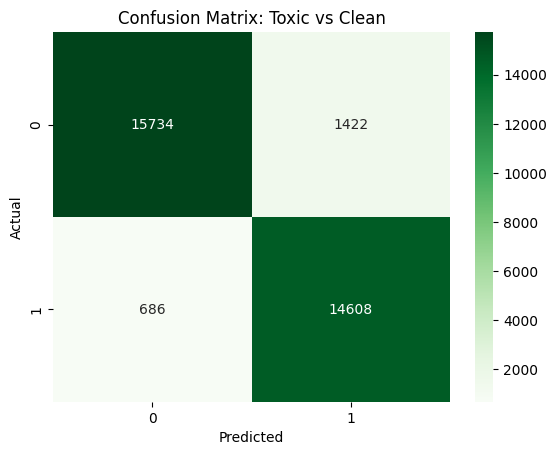

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred_probs = model.predict(X_bal)
y_pred_bin = (y_pred_probs[:, 0] > 0.5).astype(int)
y_true_bin = y_bal[:, 0]

cm = confusion_matrix(y_true_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Toxic vs Clean')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, log_loss

auc = roc_auc_score(y_bal, y_pred_probs)
loss = log_loss(y_bal, y_pred_probs)

print(f"Professional ROC-AUC: {auc:.4f}") 
print(f"Professional Log Loss: {loss:.4f}")

Professional ROC-AUC: 0.9667
Professional Log Loss: 0.3933


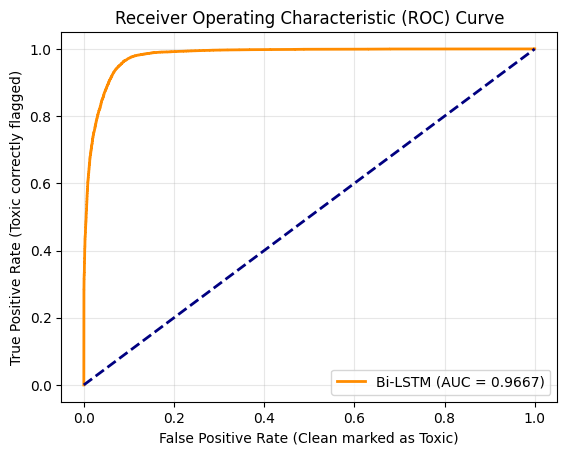

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# We'll plot the curve for the 'Toxic' class
fpr, tpr, thresholds = roc_curve(y_bal[:, 0], y_pred_probs[:, 0])

plt.plot(fpr, tpr, label=f'Bi-LSTM (AUC = {auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Clean marked as Toxic)')
plt.ylabel('True Positive Rate (Toxic correctly flagged)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#testing
def check_all_categories(text):
    categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=200)
    prediction = model.predict(padded, verbose=0)[0]

    print(f"Analysis for: '{text}'")
    for i, prob in enumerate(prediction):
        
        label = "🚩 HIGH" if prob > 0.5 else "✅ LOW"
        print(f"{categories[i]:<15}: {prob*100:>6.2f}% {label}")
    print("-" * 30)
check_all_categories("I love you but i will kill u")

Analysis for: 'I love you but i will kill u'
toxic          :  97.12% 🚩 HIGH
severe_toxic   :  18.30% ✅ LOW
obscene        :  19.18% ✅ LOW
threat         :  95.48% 🚩 HIGH
insult         :  12.55% ✅ LOW
identity_hate  :   6.37% ✅ LOW
------------------------------


In [ ]:
from sklearn.metrics import classification_report


y_pred_test = model.predict(X_bal)
y_pred_bin = (y_pred_test > 0.5).astype(int)

categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
print(classification_report(y_bal, y_pred_bin, target_names=categories))

1015/1015 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step
               precision    recall  f1-score   support

        toxic       0.91      0.96      0.93     15294
 severe_toxic       0.60      0.36      0.45      1595
      obscene       0.87      0.86      0.86      8449
       threat       0.53      0.51      0.52       478
       insult       0.78      0.82      0.80      7877
identity_hate       0.64      0.43      0.51      1405

    micro avg       0.85      0.85      0.85     35098
    macro avg       0.72      0.66      0.68     35098
 weighted avg       0.84      0.85      0.84     35098
  samples avg       0.41      0.42      0.41     35098



In [ ]:

custom_threshold = 0.25
y_pred_identity = y_pred_test[:, 5] 
y_pred_custom = (y_pred_identity > custom_threshold).astype(int)

from sklearn.metrics import recall_score, precision_score
print(f"New Recall at {custom_threshold}: {recall_score(y_bal[:, 5], y_pred_custom):.2f}")
print(f"New Precision at {custom_threshold}: {precision_score(y_bal[:, 5], y_pred_custom):.2f}")

New Recall at 0.25: 0.67
New Precision at 0.25: 0.52


In [ ]:
from google.colab import files

# 1. Save them first
model.save('bilstm_final_balanced.keras')
with open('tokenizer_final.pickle', 'wb') as handle:
    import pickle
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 2. Download them to your computer
files.download('bilstm_final_balanced.keras')
files.download('tokenizer_final.pickle')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>